####file to check the image charge 3d boundary conditions for a sheet of charge

In [14]:
from config import *

from Image_charge_3d import *

import scipy.integrate

In [15]:
class ct_in_medium2(Image_charge_calculator):

    def calc_image_charge_ct_med2(self):

        q20 = self.q_ct
        z20 = self.z_ct
        level = 0

        q21 = self.q_ct*self.alpha23
        z21 = 2*self.c - self.z_ct
        level = 0

        q31 = self.q_ct*self.beta23
        z31 = self.z_ct
        level = 0

        self.image_charges_q2s.append((q20, z20, level, 'q2j'))
        self.image_charges_q2s.append((q21, z21, level, 'q2j'))
        self.image_charges_q3s.append((q31, z31, level, 'q3j'))
        self.rule_ii(q20, z20, level + 1)
        self.rule_ii(q21, z21, level + 1)
        self.rule_iii(q31, z31, level + 1)

        ###dont need to specify potential or e field because i dont need it for this 

        return self.image_charges_q5s, self.image_charges_q4s, self.image_charges_q3s, self.image_charges_q2s, self.image_charges_q1s

In [16]:
class potential_due_sheet_ct2: 

    def __init__(self, d, charge_density, ep_qw = 11.7, ep_sige= 11.7, ep_ox=8, t_sige=10, t_ox=15):

        self.d = d   ## charge sheet is placed at a distance d 
        self.cd = charge_density 
        self.ep_qw = ep_qw
        self.ep_sige = ep_sige
        self.ep_ox= ep_ox
        self.t_sige = t_sige
        self.t_ox = t_ox

    def image_charge(self,  xp, yp):

        img_charge = ct_in_medium2(q_ct=1, z_ct=self.d, y_ct = yp, x_ct= xp, ep_qw = self.ep_qw, ep_sige= self.ep_sige, ep_ox=self.ep_ox, t_sige=self.t_sige, t_ox=self.t_ox, r=1e-3).calc_image_charge_ct_med2()

        return img_charge


    def greens_function(self, x, y, z, xp, yp):
        #### please note, this is only the green's function part, no charge density invovled
        #### for Sheet of charge, charge density is constant. 
        #### Therefore a charge density prefactor(in C/nm^2) should be multiplied out front after integrating the Greens function to find potential

        img_charge = ct_in_medium2(q_ct=1, z_ct=self.d, y_ct = yp, x_ct= xp, ep_qw = self.ep_qw, ep_sige= self.ep_sige, ep_ox=self.ep_ox, t_sige=self.t_sige, t_ox=self.t_ox, r=1e-3).calc_image_charge_ct_med2()
        
        Gfn = 0

        if z <= self.t_ox :

            #print('a')

            for ic in img_charge[2]:  
                ### q3s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)

            for ic in img_charge[1]:
                ### q4s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)
        
        elif z <= (self.t_ox+ self.t_sige) and z> self.t_ox :

            for ic in img_charge[3]:  
                ### q2s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)

            for ic in img_charge[4]:
                ### q1s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)

        else :

            for ic in img_charge[0]:
                ### q5s

                Gfn = Gfn + ic[0]/math.sqrt((x- xp)**2+(y- yp)**2+(z-ic[1])**2)
       
        return Gfn 


    def integrate_greens_function(self, x, y, z, xp_min, xp_max, yp_min, yp_max):

        #### please note, this is the integration of only the green's function part, no charge density invovled
        #### for Sheet of charge, charge density is constant. 
        #### Therefore a charge density prefactor(in C/nm^2) should be multiplied out front after integrating the Greens function to find potential

        result, error = scipy.integrate.dblquad(
            lambda xp, yp: self.greens_function(x, y, z, xp, yp),
            yp_min, yp_max,  # Integration limits for yp (outer integral)
            lambda yp: xp_min, lambda yp: xp_max  # Integration limits for xp (inner integral)
        )

        Area = (xp_max-xp_min)*(yp_max-yp_min)

        if z <= self.t_ox :

            result = 1/self.ep_ox/4/np.pi*result

        elif z<= (self.t_ox+self.t_sige) and z>self.t_ox:

            result = 1/self.ep_sige/4/np.pi*result

        else:

            result = 1/self.ep_qw/4/np.pi*result


        return result, error
    
    def integrate_gfn_simps(self, x, y, z, xp_min, xp_max, yp_min, yp_max, num_points):

        #### please note, this is the integration of only the green's function part, no charge density invovled
        #### for Sheet of charge, charge density is constant. 
        #### Therefore a charge density prefactor(in C/nm^2) should be multiplied out front after integrating the Greens function to find potential

        xp_vals = np.linspace(xp_min, xp_max, num_points)
        yp_vals = np.linspace(yp_min, yp_max, num_points)
        xp_grid, yp_grid = np.meshgrid(xp_vals, yp_vals)

        greens_values = np.vectorize(self.greens_function)(x, y, z, xp_grid, yp_grid)
        result =  scipy.integrate.simps(scipy.integrate.simps(greens_values, yp_vals), xp_vals)
        if z <= self.t_ox :

            result = 1/self.ep_ox/4/np.pi*result

        elif z<= (self.t_ox+self.t_sige) and z>self.t_ox:

            result = 1/self.ep_sige/4/np.pi*result

        else:

            result = 1/self.ep_qw/4/np.pi*result


        return result

    
    def integrate_gfn_trapz(self, x, y, z, xp_min, xp_max, yp_min, yp_max, num_points):
        #### please note, this is the integration of only the green's function part, no charge density invovled
        #### for Sheet of charge, charge density is constant. 
        #### Therefore a charge density prefactor(in C/nm^2) should be multiplied out front after integrating the Greens function to find potential

        xp_vals = np.linspace(xp_min, xp_max, num_points)
        yp_vals = np.linspace(yp_min, yp_max, num_points)
        xp_grid, yp_grid = np.meshgrid(xp_vals, yp_vals)

        greens_values = np.vectorize(self.greens_function)(x, y, z, xp_grid, yp_grid)
        result = np.trapz(np.trapz(greens_values, yp_vals), xp_vals)

        if z <= self.t_ox :

            result = 1/self.ep_ox/4/np.pi*result

        elif z<= (self.t_ox+self.t_sige):

            result = 1/self.ep_sige/4/np.pi*result

        else:

            result = 1/self.ep_qw/4/np.pi*result


        return result




In [17]:
D = 12   ###location of charge trap 
X = 0  
Y = 0   

epsilon = 3e-5  # A tiny shift

#Z = np.linspace(0, 29, 21) + epsilon
#Z = np.linspace(0, 29, 21) + epsilon

Z_test = 12

print(Z_test)

SIG = 1


Mod_test = potential_due_sheet_ct2(D, SIG, ep_ox=8, t_ox=8, t_sige=10)

charge_test = Mod_test.image_charge(1,1)

for i in range(5):
    print(charge_test[i])

12
[(1.0, 12, 1, 'q5k'), (0.1878172588832487, 4, 1, 'q5k'), (-0.0012004536028242816, -76, 11, 'q5k'), (-0.006391604317740095, -60, 9, 'q5k'), (-0.03403097434039997, -44, 7, 'q5k'), (-0.1811919444610485, -28, 5, 'q5k'), (-0.9647246772655828, -12, 3, 'q5k')]
[(-0.8121827411167513, -12, 1, 'q4j'), (-0.15254193614883144, -28, 3, 'q4j'), (-0.02865000831221707, -44, 5, 'q4j'), (-0.0053809660281829005, -60, 7, 'q4j'), (-0.0010106382895571943, -76, 9, 'q4j'), (-0.00018981531326708724, -92, 11, 'q4j')]
[(0.8121827411167513, 12, 0, 'q3j'), (0.15254193614883144, 28, 2, 'q3j'), (0.02865000831221707, 44, 4, 'q3j'), (0.0053809660281829005, 60, 6, 'q3j'), (0.0010106382895571943, 76, 8, 'q3j'), (0.00018981531326708724, 92, 10, 'q3j')]
[(1, 12, 0, 'q2j'), (0.1878172588832487, 4, 0, 'q2j'), (-0.9647246772655828, -12, 2, 'q2k'), (-0.1811919444610485, -28, 4, 'q2k'), (-0.03403097434039997, -44, 6, 'q2k'), (-0.006391604317740095, -60, 8, 'q2k'), (-0.0012004536028242816, -76, 10, 'q2k')]
[(-0.0, 24, 1, 'q1j

[3.000000e-05 2.400030e+00 4.800030e+00 7.200030e+00 9.600030e+00
 1.200003e+01 1.440003e+01 1.680003e+01 1.920003e+01 2.160003e+01
 2.400003e+01]
0
3


C:\Users\Vivrekar\AppData\Roaming\Python\Python312\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


6
9


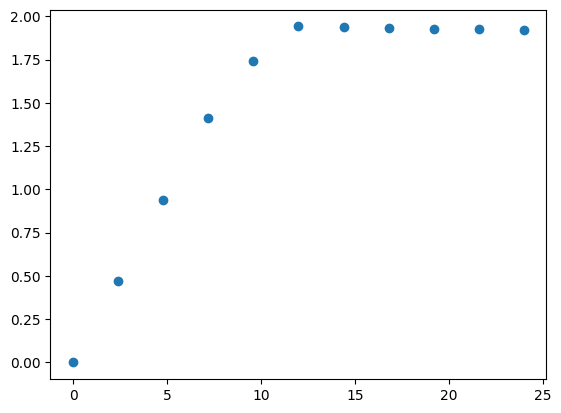

In [18]:
D = 12   ###location of charge trap 
X = 0  
Y = 0   

epsilon = 3e-5  # A tiny shift

#Z = np.linspace(0, 29, 21) + epsilon
Z = np.linspace(0, 24, 11) + epsilon

print(Z)

SIG = 1

XP_MIN= -1000
XP_MAX = 1000
YP_MIN = -1000
YP_MAX = 1000

Mod = potential_due_sheet_ct2(D, SIG, ep_ox=5, t_ox=8, t_sige=10)
V = np.empty((Z.shape[0]))
err = np.empty_like(V)
err =  np.empty((Z.shape[0]))

for i in range(Z.shape[0]):

    #V[i] = Mod.integrate_gfn_simps(X, Y, Z[i], XP_MIN, XP_MAX, YP_MIN, YP_MAX,1000)

    V[i], err[i] = Mod.integrate_greens_function(X, Y, Z[i], XP_MIN, XP_MAX, YP_MIN, YP_MAX)

    if i%3 == 0:

        print(i)

#np.save("potential_infXinf_sheet_in_Front_of_conductor_no_counts.npy", V)
plt.scatter(Z, V)

In [19]:
print(np.round(err))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


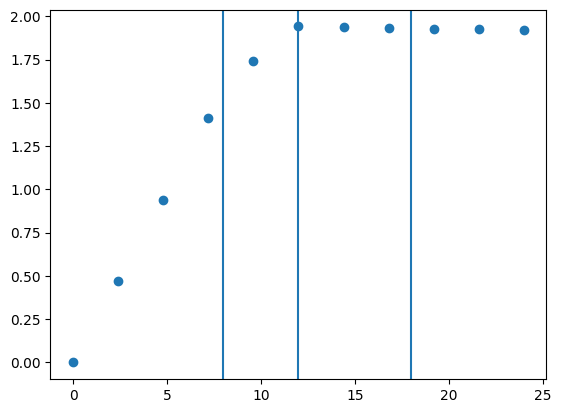

In [20]:
#plt.plot(Z, V)
plt.scatter(Z, V)
plt.axvline(x=8)
plt.axvline(x=12)
plt.axvline(x=18)

array([ 0.196,  0.196,  0.196,  0.138,  0.084, -0.002, -0.002, -0.002,
       -0.002, -0.002])

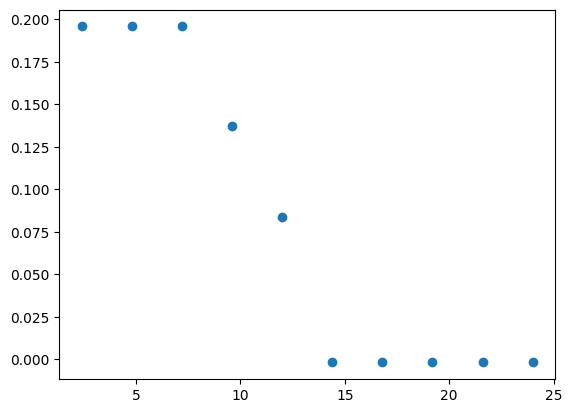

In [21]:
E = np.diff(V) / np.diff(Z)

plt.scatter(Z[1:], E)

np.round(E,3)

In [22]:
### for oxide with dielectric 5 and charge desity 1C/nm^2
print("Electric field due to charge sheet = ", 1/5)

Electric field due to charge sheet =  0.2


In [23]:
### for material with dielectric 8 and charge desity 1C/nm^2
print("Electric field due to charge sheet = ", 1/8)

Electric field due to charge sheet =  0.125
